**Week 3**

Date: 2025/7/17 

Objectives this week: 
- ABC posterior estimation with traditional rejection sampling and MCMC.
    - 1D and 2D
- mini falcon exploration and experiments
- experiments with known optimal summary statistics models
    - 1D and 2D Gaussian (known mean and variance/covariance)
    - Poisson (known rate)
    - Exponential (known scale parameters)
    - Compare NN learned and analytical summary statistics for each model

**ABC posterior estimation with rejection and MCMC sampling**

arithemetic mean value found using ABC with rejection algorithm: tensor(0.4850)


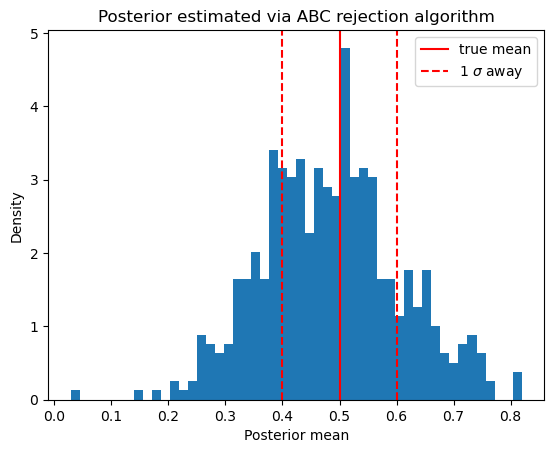

In [76]:
# 1D with rejection sampling
import torch
from sbi import utils as utils
import matplotlib.pyplot as plt
import numpy as np
torch.random.manual_seed(13)

num_dim = 1
num_points = 10000
true_theta = 0.5 *torch.ones(num_dim)
true_sd = 0.1 *torch.ones(num_dim)
x_obs = torch.normal(mean=true_theta, std=true_sd)

prior = utils.BoxUniform(low=-2*torch.ones(num_dim), high=2*torch.ones(num_dim))

def simulator(theta):
    return theta + true_sd * torch.randn_like(theta)

# in 1D case, reject x_sim points if > true_sd away from x_obs

def rejection(x_obs, prior, epsilon=true_sd, N=num_points):
    accept = []  # to store accepted theta's

    for _ in range(N):
        theta = prior.sample((1,))
        x_sim = simulator(theta)
        if torch.norm(x_sim - x_obs) < epsilon:
            accept.append(theta)
    return torch.cat(accept, dim=0)
            
posterior = rejection(x_obs, prior)
print('arithemetic mean value found using ABC with rejection algorithm:',torch.mean(posterior))

plt.figure()
plt.hist(posterior, density=True, bins=50)
plt.xlabel('Posterior mean')
plt.ylabel('Density')
plt.title('Posterior estimated via ABC rejection algorithm')
plt.axvline(x=0.5, color='red', label='true mean')
plt.axvline(x=0.4, color='red', ls='--', label='1 $\sigma$ away')
plt.axvline(x=0.6, color='red', ls='--')
# plt.xlim(-2,2)
plt.legend()
plt.show()

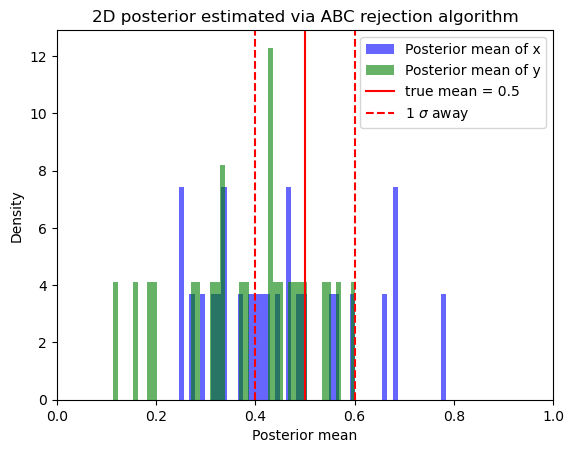

In [63]:
# 2D with rejection
torch.random.manual_seed(13)

num_dim = 2
num_points = 10000**2
true_theta = 0.5 * torch.ones(num_dim)
true_sd = 0.1 * torch.ones(num_dim)
x_obs_2D = torch.normal(mean=true_theta, std=true_sd)

prior_2D = utils.BoxUniform(low=-2*torch.ones(num_dim), high=2*torch.ones(num_dim))

posterior_2D = rejection(x_obs_2D, prior_2D)

x, y = [], []
for vector in posterior_2D:
    x.append(vector[0])
    y.append(vector[1])

plt.figure()
plt.hist(x, density=True, bins=50, color='blue', alpha=0.6, label='Posterior mean of x')
plt.hist(y, density=True, bins=50, color='green', alpha=0.6, label='Posterior mean of y')
plt.xlabel('Posterior mean')
plt.ylabel('Density')
plt.title('2D posterior estimated via ABC rejection algorithm')
plt.axvline(x=0.5, color='red', label='true mean = 0.5')
plt.axvline(x=0.4, color='red', ls='--', label='1 $\sigma$ away')
plt.axvline(x=0.6, color='red', ls='--')
plt.xlim(0,1)
plt.legend()
plt.show()

2D version seems to be converging less well than 1D, even though the number of data points is squared, with the mean in y (2nd dimension) deviating to about 0.42. Noticeably a lot fewer points pass the rejection method in this 2D algorithm as the algo becomes more sensitive to deviations in simulated data.
Curse of dimensionality already showing its power in 2D!?

In [ ]:
# with MCMC
import sbi
from sbi.inference import SNPE, simulate_for_sbi, prepare_for_sbi
from sbi import analysis as analysis
torch.random.manual_seed(13)
import torch
from sbi import utils as utils

# 1D case
num_dim = 1
num_points = 100000
true_theta = 0.5 *torch.ones(num_dim)
true_sd = 0.1 *torch.ones(num_dim)
x_obs = torch.normal(mean=true_theta, std=true_sd)

prior = utils.BoxUniform(low=-2*torch.ones(num_dim), high=2*torch.ones(num_dim))
simulator, prior = prepare_for_sbi(simulator, prior)
theta_1D, x_1D = simulate_for_sbi(simulator, prior, num_simulations=num_points)

inference = SNPE(prior=prior)
DE = inference.append_simulations(theta_1D, x_1D).train()
# sampling wirh MCMC
sampling_algorithm = "mcmc"
mcmc_method = "slice_np"
posterior_1D_MCMC = inference.build_posterior(sample_with=sampling_algorithm, 
                                              mcmc_method=mcmc_method,
                                              mcmc_parameters={"num_chains": 1, "thin": 1, "warmup_steps": 100})


Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 54 epochs.

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/10100 [00:00<?, ?it/s]

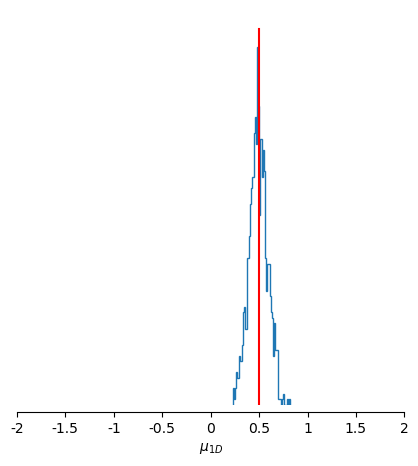

In [75]:
sample_1D = posterior_1D_MCMC.set_default_x(x_obs).sample((1000,))
fig, ax = analysis.pairplot(
    sample_1D,
    points=true_theta,
    points_colors='r',
    labels=["$\mu_{1D}$"],
    limits=[[-2,2]],
    figsize=(5, 5),
)

MCMC sampling method obviously give a much better convergence and estimate of the true parameter, however the runtime is much longer for collecting a data size of 1000.